# Task 2: Generative Model Baseline (Ollama version)

This notebook establishes the stand-alone generative baseline for the TextWave project. Unlike the retrieval-focused analysis in Task 1, the purpose here is to evaluate what the available language models can answer when they receive only the question itself and no retrieved supporting context. In other words, this is a no-RAG benchmark: it measures the models' question-answering ability before retrieval augmentation is introduced in later tasks.

The notebook uses the OpenAI-compatible Ollama client, compares ``phi3:mini`` and ``qwen2.5:1.5b`` under the same non-RAG setup, scores their outputs against the evaluation file ``question.tsv``, and reports both overall and difficulty-stratified results. The goal is to perform a comparative study between these two generator, choose the better performing model and establish a baseline for assessing whether the retrieval-augmented systems in later sections genuinely improve answer quality over direct generation alone.

### Imports and paths

In [1]:
import os
import sys
import time
import subprocess
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
# Project root and paths
# Intended notebook location: PROJECT_ROOT/analysis/task2.ipynb
# Run from: PROJECT_ROOT/analysis

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUESTIONS_PATH = PROJECT_ROOT / "textwave" / "qa_resources" / "question.tsv"
RESULTS_DIR = PROJECT_ROOT / "analysis" / "results" / "task2_openai_ollama"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["phi3:mini", "qwen2.5:1.5b"]
OLLAMA_BASE_URL = "http://localhost:11434/v1"
OLLAMA_API_KEY = "ollama"
GENERATION_TEMPERATURE = 0.2

print("PROJECT_ROOT:", PROJECT_ROOT)
print("QUESTIONS_PATH exists:", QUESTIONS_PATH.exists())
print("RESULTS_DIR:", RESULTS_DIR)
print("Models:", MODEL_NAMES)


PROJECT_ROOT: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main
QUESTIONS_PATH exists: True
RESULTS_DIR: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task2_openai_ollama
Models: ['phi3:mini', 'qwen2.5:1.5b']


In [3]:
# Install/import dependencies used by the generator and evaluator
import sys
import subprocess

try:
    from openai import OpenAI
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openai"])
    from openai import OpenAI

try:
    from textwave.modules.utils.metrics import Matching
except ModuleNotFoundError as e:
    if "qa_metrics" in str(e):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "qa-metrics"])
        from textwave.modules.utils.metrics import Matching
    else:
        raise


## Generator implementation

The next cell includes the grader-required `QAGeneratorOpenAI` class pattern, then defines a minimal `QAGeneratorOpenAIStandalone` subclass for Task 2.

Why the subclass is needed:
- the provided script is context-based
- Task 2 must be **stand-alone / no RAG**
- so the subclass removes the context dependence while preserving the required OpenAI-compatible Ollama client 

We used an OpenAI-compatible generator class based on the one provided in the assignment file ``question_answering.py`` but adapted to point to a local Ollama server. Although the class still accepts a `context` argument for consistency with later RAG tasks, we intentionally removed it: the model receives only the question, which ensures that the experiment is a genuine no-retrieval baseline. We also simplified the prompt accordingly. In the original module, the prompt explicitly constrained the model to answer only from the provided context and to return ``No context`` when the answer was absent. For this task, that instruction would have been inappropriate, since no retrieved evidence is supplied. The prompt was therefore reduced to a much lighter instruction.

In [4]:
from openai import OpenAI

import time
from typing import List

from openai import OpenAI


class QAGeneratorOpenAI:
    """
    A question-answer generator that uses the OpenAI-compatible API
    (OpenAI or local Ollama) to generate answers based on query only (no context).
    """
    def __init__(
        self,
        api_key: str = "ollama",
        temperature: float = 0.3,
        generator_model: str = "phi3:mini",  # or qwen2.5:1.5b
        base_url: str = "http://localhost:11434/v1"
    ):
        self.api_key = api_key
        self.temperature = temperature
        self.generator_model = generator_model

        self.client = OpenAI(
            api_key=api_key,
            base_url=base_url
        )

    def generate_answer(self, query: str, context: List[str]) -> str:
        combined_input = (
            f"Question: {query}\n\n"
        )

        response = self.client.chat.completions.create(
            model=self.generator_model,
            temperature=self.temperature,
            max_tokens=120,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "Provide clear, concise, and full-sentence answers."
                    ),
                },
                {
                    "role": "user",
                    "content": combined_input,
                },
            ],
        )

        time.sleep(2)
        return response.choices[0].message.content.strip()


In [5]:
# Load questions
questions = pd.read_csv(QUESTIONS_PATH, sep="\t")
print("Columns:", questions.columns.tolist())
display(questions.head())
print("Number of questions:", len(questions))


Columns: ['ArticleTitle', 'Question', 'Answer', 'DifficultyFromQuestioner', 'DifficultyFromAnswerer', 'ArticleFile']


,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4


Number of questions: 1051


The display above allows us to inspect the structure of ``question.tsv`` before any preprocessing or scoring is applied. The printed column list shows that each row contains not only the question and its reference answer, but also metadata about the source article and the question's difficulty. In particular, ``ArticleFile`` identifies the source document associated with the question, while ``DifficultyFromQuestioner`` and ``DifficultyFromAnswerer`` provide two difficulty annotations available in the dataset. We use the latter as the ground truth for difficulty.

The preview of the first rows helps clarify what one unit of evaluation looks like. Each row corresponds to a single question-answer pair linked to a specific source article. The sample also shows that some questions appear in closely related forms, with small differences in answer formatting such as ``yes`` versus ``Yes.``. Later evaluation therefore does not rely on raw character-for-character equality alone: instead, the notebook passes answers through the project's ``Matching`` evaluator, using ``matcher.exact_match()`` for lexical agreement and ``matcher.transformer_match()`` for semantic equivalence. No separate manual normalization step is implemented in the notebook itself beyond basic text-safety handling: the scoring logic is delegated to the matcher and its underlying QA-metrics utilities.

Next step standardizes the input before evaluation.

In [6]:
# Resolve key columns safely
def pick_first_existing(df: pd.DataFrame, candidates: List[str], field_name: str) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Could not find a column for {field_name}. Tried: {candidates}. Available: {df.columns.tolist()}")

QUESTION_COL = pick_first_existing(
    questions,
    ["Question"],
    "question text",
)

ANSWER_COL = pick_first_existing(
    questions,
    ["Answer"],
    "reference answer",
)

DIFFICULTY_COL = pick_first_existing(
    questions,
    ["DifficultyFromAnswerer"],
    "difficulty label",
)

print("QUESTION_COL:", QUESTION_COL)
print("ANSWER_COL:", ANSWER_COL)
print("DIFFICULTY_COL:", DIFFICULTY_COL)


QUESTION_COL: Question
ANSWER_COL: Answer
DIFFICULTY_COL: DifficultyFromAnswerer


Let us now perform a basic sanity check on the question dataset before running generation and evaluation. This snippet reports the total number of rows, the distribution of difficulty labels, and the amount of missing data in the key fields identified earlier. The purpose is to understand the shape and quality of the dataset before interpreting any model results.

In [7]:
# Dataset sanity checks
print("Total questions:", len(questions))
print("\nDifficulty distribution:")
display(questions[DIFFICULTY_COL].value_counts(dropna=False).rename_axis(DIFFICULTY_COL).reset_index(name="count"))

print("\nMissing values:")
print(f"Missing question text: {questions[QUESTION_COL].isna().sum()}")
print(f"Missing reference answers: {questions[ANSWER_COL].isna().sum()}")
print(f"Missing difficulty labels: {questions[DIFFICULTY_COL].isna().sum()}")


Total questions: 1051

Difficulty distribution:


,DifficultyFromAnswerer,count
0,easy,322
1,medium,304
2,NaN,210
3,hard,184
4,too hard,25
5,too easy,6



Missing values:
Missing question text: 17
Missing reference answers: 211
Missing difficulty labels: 210


The dataset contains 1051 questions in total. The largest labeled groups are ``easy`` with 322 questions and ``medium`` with 304, followed by ``hard`` with 184. There are also two small auxiliary categories, ``too hard`` with 25 questions and ``too easy`` with 6. A notable feature of the data is that 210 rows have no difficulty label at all, which is why the difficulty-based analysis later needs to be interpreted with some care.

The missing-value summary is also important. Only 17 rows are missing question text, so the main input field is almost complete. By contrast, 211 rows are missing reference answers, which is a substantial number because answer-based evaluation depends directly on having a gold target. The 210 missing difficulty labels match the unlabeled group in the distribution above. The raw file is large enough for a meaningful stand-alone baseline, but not every row is equally usable for every type of analysis: overall generation can still be studied broadly, whereas answer-based scoring and difficulty-stratified evaluation require more caution or filtering.

### Matcher and helpers

Here we set up the answer-scoring subroutine. It initializes the provided `Matching` evaluator and defines helper functions that make the scoring process robust to missing or irregular values. The `safe_text` function standardizes inputs by converting nulls and non-string values into a clean textual form, while `score_single_answer` applies the two main evaluation metrics, Exact Match and Transformer Match, to one generated answer at a time and stores the results in a consistent dictionary format. This creates a reusable scoring unit that can later be applied across the full dataset and then aggregated overall or by difficulty.


In [8]:
# Evaluator and helpers
matcher = Matching()

def safe_text(x) -> str:
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return x if isinstance(x, str) else str(x)

def score_single_answer(question: str, gold_answer: str, generated_answer: str) -> Dict[str, Any]:
    question = safe_text(question)
    gold_answer = safe_text(gold_answer)
    generated_answer = safe_text(generated_answer)

    em = matcher.exact_match(generated_answer, gold_answer)

    try:
        transformer_scores, transformer_match = matcher.transformer_match(
            generated_answer=generated_answer,
            ground_truth_answer=gold_answer,
            question=question,
        )
    except Exception:
        transformer_scores = None
        transformer_match = np.nan

    score_dict = {
        "exact_match": float(bool(em)),
        "transformer_match": float(bool(transformer_match)) if not pd.isna(transformer_match) else np.nan,
    }

    if transformer_scores is not None:
        if isinstance(transformer_scores, dict):
            for k, v in transformer_scores.items():
                try:
                    score_dict[f"transformer_score_{k}"] = float(v)
                except Exception:
                    pass
        elif isinstance(transformer_scores, (list, tuple, np.ndarray)):
            for i, v in enumerate(transformer_scores):
                try:
                    score_dict[f"transformer_score_{i}"] = float(v)
                except Exception:
                    pass
        else:
            try:
                score_dict["transformer_score"] = float(transformer_scores)
            except Exception:
                pass

    return score_dict


Using device: cpu


We perform a quick smoke test before launching the full experiment. The following snippet sends a single sample question to each model, checks that the generator returns a response without error, and records the response time. The purpose is to verifies that the Ollama connection, model loading, and generation call all work as expected.

In [9]:
# Smoke test
sample_question = safe_text(questions.iloc[0][QUESTION_COL])

for model_name in MODEL_NAMES:
    print(f"\nTesting model: {model_name}")
    try:
        generator = QAGeneratorOpenAI(
            api_key=OLLAMA_API_KEY,
            temperature=GENERATION_TEMPERATURE,
            generator_model=model_name,
            base_url=OLLAMA_BASE_URL,
        )
        start = time.perf_counter()
        answer = generator.generate_answer(sample_question, context=[])
        latency = time.perf_counter() - start
        print("Answer preview:", answer[:300])
        print("Latency (sec):", round(latency, 3))
    except Exception as exc:
        print(f"Smoke test failed for {model_name}: {exc}")



Testing model: phi3:mini
Answer preview: Yes, Abraham Lincoln was indeed the sixteenth President of the United States. He served from March 1861 until his assassination in April 1935. His presidency is most noted for leading the country through the Civil War and working towards abolishing slavery with the Emancipation Proclamation.
Latency (sec): 15.858

Testing model: qwen2.5:1.5b
Answer preview: Yes, Abraham Lincoln was indeed the sixteenth President of the United States. He served from 1861 to 1865 during the American Civil War.
Latency (sec): 8.652


### Baseline runner

In [10]:
# Baseline runner
def run_model_baseline(
    model_name: str,
    questions_df: pd.DataFrame,
    question_col: str,
    answer_col: str,
    difficulty_col: str,
    save_csv: bool = True,
    save_every: int = 25,
    print_every: int = 10,
) -> pd.DataFrame:
    rows = []
    total = len(questions_df)

    generator = QAGeneratorOpenAI(
        api_key=OLLAMA_API_KEY,
        temperature=GENERATION_TEMPERATURE,
        generator_model=model_name,
        base_url=OLLAMA_BASE_URL,
    )

    safe_model_name = model_name.replace(":", "_").replace("/", "_")
    final_path = RESULTS_DIR / f"{safe_model_name}_baseline_results.csv"
    partial_path = RESULTS_DIR / f"{safe_model_name}_baseline_results_partial.csv"

    start_all = time.perf_counter()

    for i, (_, row) in enumerate(questions_df.iterrows(), start=1):
        question_text = safe_text(row[question_col])
        gold_answer = safe_text(row[answer_col])
        difficulty = safe_text(row[difficulty_col]).lower().strip()

        item_start = time.perf_counter()

        try:
            generated_answer = safe_text(generator.generate_answer(question_text, context=[]))
            latency_sec = time.perf_counter() - item_start
            generation_error = ""
        except Exception as exc:
            generated_answer = ""
            latency_sec = np.nan
            generation_error = str(exc)

        score_row = score_single_answer(
            question=question_text,
            gold_answer=gold_answer,
            generated_answer=generated_answer,
        )

        result_row = {
            "row_id": int(i - 1),
            "model": model_name,
            "question": question_text,
            "gold_answer": gold_answer,
            "difficulty": difficulty,
            "generated_answer": generated_answer,
            "latency_sec": latency_sec,
            "generation_error": generation_error,
            "row_elapsed_sec": latency_sec,
        }
        result_row.update(score_row)
        rows.append(result_row)

        if i % print_every == 0 or i == 1 or i == total:
            elapsed = time.perf_counter() - start_all
            avg = elapsed / i
            remaining = avg * (total - i)
            print(
                f"[{model_name}] {i}/{total} done | "
                f"elapsed: {elapsed/60:.1f} min | "
                f"avg/question: {avg:.2f} sec | "
                f"eta: {remaining/60:.1f} min",
                flush=True,
            )

        if save_csv and (i % save_every == 0 or i == total):
            pd.DataFrame(rows).to_csv(partial_path, index=False)
            print(f"Saved partial results to: {partial_path}")

    results_df = pd.DataFrame(rows)

    if save_csv:
        results_df.to_csv(final_path, index=False)
        print(f"Saved final results to: {final_path}")

    total_elapsed = time.perf_counter() - start_all
    print(f"[{model_name}] completed {total} questions in {total_elapsed/60:.1f} minutes.")

    return results_df


In [11]:
# Run phi3:mini baseline
phi3_results = run_model_baseline(
    model_name="phi3:mini",
    questions_df=questions,
    question_col=QUESTION_COL,
    answer_col=ANSWER_COL,
    difficulty_col=DIFFICULTY_COL,
    save_csv=True,
    save_every=25,
    print_every=10,
)

display(phi3_results.head())
print("Rows:", len(phi3_results))


[phi3:mini] 1/1051 done | elapsed: 0.1 min | avg/question: 8.76 sec | eta: 153.3 min
[phi3:mini] 10/1051 done | elapsed: 2.3 min | avg/question: 14.09 sec | eta: 244.5 min
[phi3:mini] 20/1051 done | elapsed: 4.7 min | avg/question: 14.04 sec | eta: 241.2 min
Saved partial results to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task2_openai_ollama\phi3_mini_baseline_results_partial.csv
[phi3:mini] 30/1051 done | elapsed: 7.0 min | avg/question: 14.03 sec | eta: 238.7 min
[phi3:mini] 40/1051 done | elapsed: 9.3 min | avg/question: 13.92 sec | eta: 234.6 min
[phi3:mini] 50/1051 done | elapsed: 11.5 min | avg/question: 13.83 sec | eta: 230.7 min
Saved partial results to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task2_openai_ollama\phi3_mini_baseline_results_partial.csv
[phi3:mini] 60/1051 done | elapsed: 13.3 min | avg/question: 13.31 sec | eta: 219.8 min
[phi3:mini] 70/1051 done | elap

,row_id,model,question,gold_answer,difficulty,generated_answer,latency_sec,generation_error,row_elapsed_sec,exact_match,transformer_match
0,0,phi3:mini,Was Abraham Lincoln the sixteenth President of...,yes,easy,"Yes, Abraham Lincoln was indeed the sixteenth ...",8.756574,,8.756574,1.0,1.0
1,1,phi3:mini,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,"Yes, Abraham Lincoln was indeed the sixteenth ...",6.719528,,6.719528,1.0,1.0
2,2,phi3:mini,Did Lincoln sign the National Banking Act of 1...,yes,medium,"No, Abraham Lincoln did not personally sign th...",7.583353,,7.583353,0.0,0.0
3,3,phi3:mini,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,"No, Abraham Lincoln did not personally sign th...",8.569146,,8.569146,0.0,0.0
4,4,phi3:mini,Did his mother die of pneumonia?,no,medium,No information is provided in the text to sugg...,8.237106,,8.237106,1.0,1.0


Rows: 1051


In [12]:
# Run qwen2.5:1.5b baseline
qwen_results = run_model_baseline(
    model_name="qwen2.5:1.5b",
    questions_df=questions,
    question_col=QUESTION_COL,
    answer_col=ANSWER_COL,
    difficulty_col=DIFFICULTY_COL,
    save_csv=True,
    save_every=25,
    print_every=10,
)

display(qwen_results.head())
print("Rows:", len(qwen_results))


[qwen2.5:1.5b] 1/1051 done | elapsed: 0.1 min | avg/question: 8.65 sec | eta: 151.3 min
[qwen2.5:1.5b] 10/1051 done | elapsed: 1.5 min | avg/question: 8.85 sec | eta: 153.6 min
[qwen2.5:1.5b] 20/1051 done | elapsed: 4.0 min | avg/question: 12.04 sec | eta: 206.9 min
Saved partial results to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task2_openai_ollama\qwen2.5_1.5b_baseline_results_partial.csv
[qwen2.5:1.5b] 30/1051 done | elapsed: 5.8 min | avg/question: 11.53 sec | eta: 196.2 min
[qwen2.5:1.5b] 40/1051 done | elapsed: 7.4 min | avg/question: 11.17 sec | eta: 188.3 min
[qwen2.5:1.5b] 50/1051 done | elapsed: 8.8 min | avg/question: 10.55 sec | eta: 176.0 min
Saved partial results to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task2_openai_ollama\qwen2.5_1.5b_baseline_results_partial.csv
[qwen2.5:1.5b] 60/1051 done | elapsed: 10.0 min | avg/question: 9.99 sec | eta: 165.1 min
[qwen2.

,row_id,model,question,gold_answer,difficulty,generated_answer,latency_sec,generation_error,row_elapsed_sec,exact_match,transformer_match
0,0,qwen2.5:1.5b,Was Abraham Lincoln the sixteenth President of...,yes,easy,"Yes, Abraham Lincoln was indeed the sixteenth ...",8.629394,,8.629394,1.0,1.0
1,1,qwen2.5:1.5b,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,"Yes, Abraham Lincoln was indeed the sixteenth ...",3.484321,,3.484321,1.0,1.0
2,2,qwen2.5:1.5b,Did Lincoln sign the National Banking Act of 1...,yes,medium,"Yes, Abraham Lincoln signed the National Banki...",4.719668,,4.719668,1.0,1.0
3,3,qwen2.5:1.5b,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,"Yes, Abraham Lincoln signed the National Banki...",4.429251,,4.429251,1.0,1.0
4,4,qwen2.5:1.5b,Did his mother die of pneumonia?,no,medium,"I'm sorry, but I don't have enough information...",5.860706,,5.860706,1.0,1.0


Rows: 1051


In [13]:
# Combine and save all results
all_results = pd.concat([phi3_results, qwen_results], ignore_index=True)

combined_path = RESULTS_DIR / "task2_combined_results.csv"
all_results.to_csv(combined_path, index=False)

print("Combined results saved to:", combined_path)
display(all_results.head())
display(all_results["model"].value_counts().rename_axis("model").reset_index(name="rows"))


Combined results saved to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task2_openai_ollama\task2_combined_results.csv


,row_id,model,question,gold_answer,difficulty,generated_answer,latency_sec,generation_error,row_elapsed_sec,exact_match,transformer_match
0,0,phi3:mini,Was Abraham Lincoln the sixteenth President of...,yes,easy,"Yes, Abraham Lincoln was indeed the sixteenth ...",8.756574,,8.756574,1.0,1.0
1,1,phi3:mini,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,"Yes, Abraham Lincoln was indeed the sixteenth ...",6.719528,,6.719528,1.0,1.0
2,2,phi3:mini,Did Lincoln sign the National Banking Act of 1...,yes,medium,"No, Abraham Lincoln did not personally sign th...",7.583353,,7.583353,0.0,0.0
3,3,phi3:mini,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,"No, Abraham Lincoln did not personally sign th...",8.569146,,8.569146,0.0,0.0
4,4,phi3:mini,Did his mother die of pneumonia?,no,medium,No information is provided in the text to sugg...,8.237106,,8.237106,1.0,1.0


,model,rows
0,phi3:mini,1051
1,qwen2.5:1.5b,1051


### Results

In [14]:
# Overall summary table
metric_cols = [c for c in all_results.columns if c.startswith("transformer_score_")]
overall_agg = {
    "row_id": "count",
    "exact_match": "mean",
    "transformer_match": "mean",
    "latency_sec": "mean",
}
for c in metric_cols:
    overall_agg[c] = "mean"

overall_summary = (
    all_results
    .groupby("model", dropna=False)
    .agg(overall_agg)
    .rename(columns={"row_id": "num_questions"})
    .reset_index()
)

display(overall_summary)


,model,num_questions,exact_match,transformer_match,latency_sec
0,phi3:mini,1051,0.284491,0.302569,8.797814
1,qwen2.5:1.5b,1051,0.297812,0.327307,5.588424


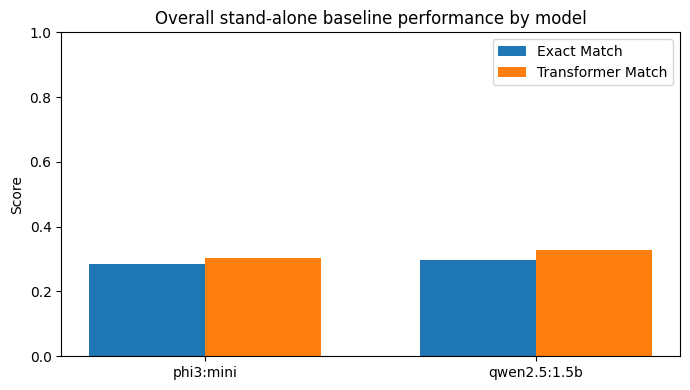

In [15]:
import matplotlib
import matplotlib.pyplot as plt

# Overall comparison figure
plot_df = overall_summary.copy()

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(plot_df))
width = 0.35

ax.bar(x - width/2, plot_df["exact_match"], width, label="Exact Match")
ax.bar(x + width/2, plot_df["transformer_match"], width, label="Transformer Match")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Overall stand-alone baseline performance by model")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
# Difficulty-stratified summary table
difficulty_summary = (
    all_results
    .groupby(["model", "difficulty"], dropna=False)
    .agg(
        num_questions=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        latency_sec=("latency_sec", "mean"),
        **{c: (c, "mean") for c in metric_cols}
    )
    .reset_index()
)

display(difficulty_summary)


,model,difficulty,num_questions,exact_match,transformer_match,latency_sec
0,phi3:mini,,210,0.009524,0.009524,8.420838
1,phi3:mini,easy,322,0.559006,0.568323,8.699494
2,phi3:mini,hard,184,0.244565,0.244565,9.483425
3,phi3:mini,medium,304,0.220395,0.269737,8.768438
4,phi3:mini,too easy,6,0.333333,0.333333,7.743664
5,phi3:mini,too hard,25,0.120000,0.160000,8.794908
6,qwen2.5:1.5b,,210,0.009524,0.009524,4.983717
7,qwen2.5:1.5b,easy,322,0.571429,0.602484,5.594034
8,qwen2.5:1.5b,hard,184,0.260870,0.282609,6.147094
9,qwen2.5:1.5b,medium,304,0.226974,0.282895,5.621380


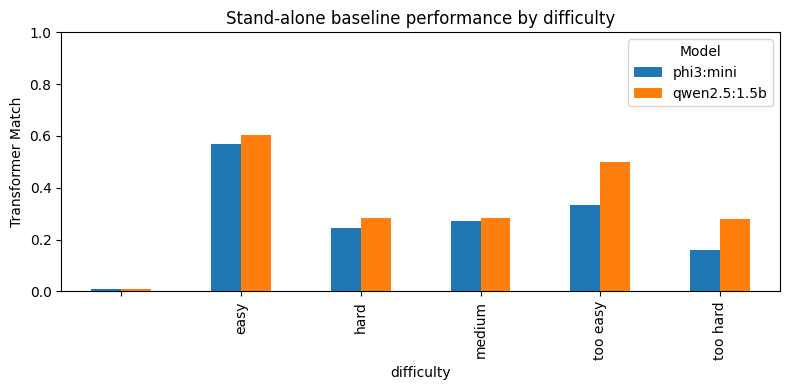

In [17]:
# Difficulty-stratified figure
plot_df = difficulty_summary.copy()
pivot_df = plot_df.pivot(index="difficulty", columns="model", values="transformer_match").sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
pivot_df.plot(kind="bar", ax=ax)

ax.set_ylim(0, 1)
ax.set_ylabel("Transformer Match")
ax.set_title("Stand-alone baseline performance by difficulty")
ax.legend(title="Model")
plt.tight_layout()
plt.show()
